<a href="https://colab.research.google.com/github/jeffheaton/app_deep_learning/blob/main/t81_558_class_10_2_face_landmarks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T81-558: Applications of Deep Neural Networks

**Module 10: Facial Processing**

* Instructor: [Jeff Heaton](https://sites.washu.edu/jeffheaton/), McKelvey School of Engineering, [Washington University in St. Louis](https://engineering.washu.edu/index.html)
* For more information visit the [class website](https://sites.washu.edu/jeffheaton/t81-558/).

# Module 10 Material

- Part 10.1: Detecting Faces in an Image [[Video]]() [[Notebook]](t81_558_class_10_1_faces.ipynb)
- **Part 10.2: Detecting Facial Features** [[Video]]() [[Notebook]](t81_558_class_10_2_face_landmarks.ipynb)
- Part 10.3: Reality Augmentation [[Video]]() [[Notebook]](t81_558_class_10_3_reality_augmentation.ipynb)
- Part 10.4: Application: Emotion Detection [[Video]]() [[Notebook]](t81_558_class_10_4_emotion.ipynb)
- Part 10.5: Dynaface [[Video]]() [[Notebook]](t81_558_class_10_5_dynaface.ipynb)

# Google CoLab Instructions

The following code checks that Google CoLab is and sets up the correct hardware settings for PyTorch.

In [1]:
try:
    import google.colab
    COLAB = True
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    COLAB = False

!pip install -q mediapipe opencv-python matplotlib requests

# Make use of a GPU or MPS (Apple) if one is available.  (see module 3.2)
import torch
has_mps = torch.backends.mps.is_available()
device = "mps" if has_mps else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Note: using Google CoLab
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 8.3 MB/s eta 0:00:00
Using device: cuda


# Part 10.2: Detecting Facial Features

In Part 10.1 we located faces in an image as bounding boxes. That is enough to know *where* a face is, but not enough to know anything about its structure. Facial landmark detection takes the next step: it identifies specific anatomically meaningful points on the face, such as the corners of the eyes, the tip of the nose, the contour of the lips, and the outline of the jawline. The geometry of these points is what unlocks downstream applications.

In this part we use Google's [MediaPipe Face Landmarker](https://ai.google.dev/edge/mediapipe/solutions/vision/face_landmarker), which produces a dense 478-point mesh covering the full face, including detail around the eyes and lips and a small set of iris landmarks. The model runs on CPU and is fast enough for real-time video, which is why it shows up in so many production pipelines for AR filters, video conferencing effects, and on-device face analysis.

Once we have a reliable set of landmarks, the door opens to a wide range of applications:

* **Facial alignment**: Landmarks let us rotate, scale, and crop a face into a canonical pose, which is a common preprocessing step for face recognition and for any downstream model that expects consistent input.
* **Emotion recognition**: The relative positions of landmarks around the eyebrows, eyes, and mouth carry most of the signal for expression classification.
* **Face morphing and augmentation**: Landmarks act as anchor points for warping one face into another, or for placing virtual masks, glasses, and makeup in apps like Snapchat and Instagram.
* **Facial animation**: In games and film, landmark trajectories drive the rig of an animated character so that the character mirrors a real performer.
* **Gaze tracking**: Eye and iris landmarks let us estimate where someone is looking, which matters for accessibility tools, driver monitoring, and UX research.
* **Medical and cosmetic analysis**: Precise landmarks support measurement of facial symmetry, surgical planning, and outcome tracking. This is the same family of techniques that powers tools like [Dynaface](https://github.com/jeffheaton/dynaface).
* **Speech and lip reading**: The dense mouth landmarks support visual speech recognition and speech therapy applications.

The rest of this notebook walks through a complete landmark detection pipeline: configure the model, download an image, run inference, and render the result.


## Configuration

Before pulling in any libraries, we collect every tunable value into one block of constants. There are several reasons to do this in a teaching notebook:

* It makes the moving parts obvious. If you want to swap in your own photo, you change `IMAGE_URL` and nothing else.
* It separates *what* the pipeline does from *how* it is configured, which keeps the helper functions below clean.
* It documents the defaults. The radius scaling, the target image width, and the number of faces to detect are all decisions, and putting them at the top forces us to be explicit about them.

A few values worth calling out:

* `IMAGE_URL` points at a sample portrait. Swap in any direct JPG or PNG URL to test on your own image.
* `MODEL_URL` is the float16 build of MediaPipe's face landmarker. The `.task` file bundles the model weights and the preprocessing graph that MediaPipe uses at inference time.
* `TARGET_WIDTH = 1024` resizes the input before inference. The model itself works on a smaller internal resolution, but resizing the display image keeps the rendered landmarks crisp without producing an oversized figure.
* `NUM_FACES = 1` tells the detector to return at most one face. Raise this if you expect group photos.
* `SHOW_LANDMARK_NUMBERS = False` is a debugging toggle. Flip it to `True` to overlay each landmark's index on the image, which is useful when you want to figure out which point corresponds to, say, the left corner of the mouth.


In [2]:
# =========================
# Constants
# =========================

IMAGE_URL = "https://data.heatonresearch.com/images/jeff/about-jeff-heaton-2020.jpg"

MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/"
    "face_landmarker/face_landmarker/float16/latest/face_landmarker.task"
)

MODEL_PATH = "face_landmarker.task"

LANDMARK_COLOR = (0, 255, 0)
LANDMARK_RADIUS_SCALE = 0.0025
LANDMARK_MIN_RADIUS = 1
LANDMARK_MAX_RADIUS = 4

SHOW_LANDMARK_NUMBERS = False
LANDMARK_FONT_SCALE = 0.35
LANDMARK_FONT_THICKNESS = 1
LANDMARK_NUMBER_OFFSET = 4

TARGET_WIDTH = 1024
NUM_FACES = 1

## Imports and helper functions

Next we bring in the libraries and define the small functions that the main pipeline will call. Splitting the work into helpers keeps the final cell short and readable, and it lets us reuse pieces (for example, `load_image_from_url`) in later notebooks in this module.

A quick tour of what each helper does:

* `download_file` fetches the MediaPipe `.task` model file from Google's CDN and writes it to local disk. MediaPipe expects a file path, not bytes in memory, so we have to materialize it.
* `load_image_from_url` downloads an image and decodes it through OpenCV. OpenCV decodes into BGR by convention, so we immediately convert to RGB. Every other piece of code in this notebook (matplotlib, MediaPipe) expects RGB, so doing the conversion once here prevents subtle color-channel bugs later.
* `resize_to_width` scales the image to a fixed width while preserving the aspect ratio. This makes the output figure size predictable across input images.
* `create_face_landmarker` builds the actual detector. Note the two flags we leave off: `output_face_blendshapes` and `output_facial_transformation_matrixes`. Blendshapes give you 52 facial expression coefficients (think rig sliders for an avatar) and the transformation matrix gives you the head's 3D pose. We do not need either for plain landmark visualization, and turning them off makes inference a bit faster.
* `draw_landmarks` annotates each detected point on a copy of the original image. The dot radius scales with image size so that the visualization looks reasonable on both small and large images.
* `display_image` is a thin wrapper around matplotlib that hides the axes and uses a square figure.

The MediaPipe model returns landmark coordinates as normalized floats in the range [0, 1]. We multiply by image width and height inside `draw_landmarks` to get pixel coordinates. This normalization is convenient because it means the same landmark indices refer to the same anatomical points regardless of input resolution.


In [3]:
# =========================
# Imports
# =========================

import cv2
import requests
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp

from mediapipe.tasks import python
from mediapipe.tasks.python import vision


# =========================
# Helper functions
# =========================

def download_file(url, path):
    response = requests.get(url)
    response.raise_for_status()

    with open(path, "wb") as f:
        f.write(response.content)


def load_image_from_url(url):
    response = requests.get(url)
    response.raise_for_status()

    image_array = np.frombuffer(response.content, np.uint8)
    bgr = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

    if bgr is None:
        raise ValueError("Could not decode image. Try a direct JPG or PNG URL.")

    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def resize_to_width(rgb, target_width):
    h, w, _ = rgb.shape

    if w == target_width:
        return rgb

    scale = target_width / w
    new_h = int(h * scale)

    return cv2.resize(rgb, (target_width, new_h), interpolation=cv2.INTER_LINEAR)


def create_face_landmarker(model_path):
    base_options = python.BaseOptions(model_asset_path=model_path)

    options = vision.FaceLandmarkerOptions(
        base_options=base_options,
        output_face_blendshapes=False,
        output_facial_transformation_matrixes=False,
        num_faces=NUM_FACES,
    )

    return vision.FaceLandmarker.create_from_options(options)


def draw_landmarks(rgb, result):
    annotated = rgb.copy()
    height, width, _ = annotated.shape

    radius = int(min(width, height) * LANDMARK_RADIUS_SCALE)
    radius = max(LANDMARK_MIN_RADIUS, min(radius, LANDMARK_MAX_RADIUS))

    for face_landmarks in result.face_landmarks:
        for i, landmark in enumerate(face_landmarks):
            x = int(landmark.x * width)
            y = int(landmark.y * height)

            cv2.circle(
                annotated,
                (x, y),
                radius,
                LANDMARK_COLOR,
                -1,
            )

            if SHOW_LANDMARK_NUMBERS:
                cv2.putText(
                    annotated,
                    str(i),
                    (x + LANDMARK_NUMBER_OFFSET, y - LANDMARK_NUMBER_OFFSET),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    LANDMARK_FONT_SCALE,
                    LANDMARK_COLOR,
                    LANDMARK_FONT_THICKNESS,
                    cv2.LINE_AA,
                )

    return annotated


def display_image(rgb):
    plt.figure(figsize=(10, 10))
    plt.imshow(rgb)
    plt.axis("off")
    plt.show()



## Running the pipeline

With the configuration and helpers in place, the actual detection is short. We download the model file once, fetch and resize the image, wrap it in a MediaPipe `Image` object (which is the input format the detector expects), build the detector, and call `detect`.

The result object contains a list of detected faces. For each face, MediaPipe returns 478 landmarks covering the face mesh, eyes, lips, and irises. We pass the result into our `draw_landmarks` helper to overlay them on the image, then display it.

The two `print` statements at the end are a quick sanity check: they confirm how many faces the detector found and how many landmarks it produced for the first one. If you swap in a group photo and bump `NUM_FACES`, you should see the first count rise; the per-face landmark count is fixed at 478 for this model.


Resized image shape: (1024, 1024, 3)


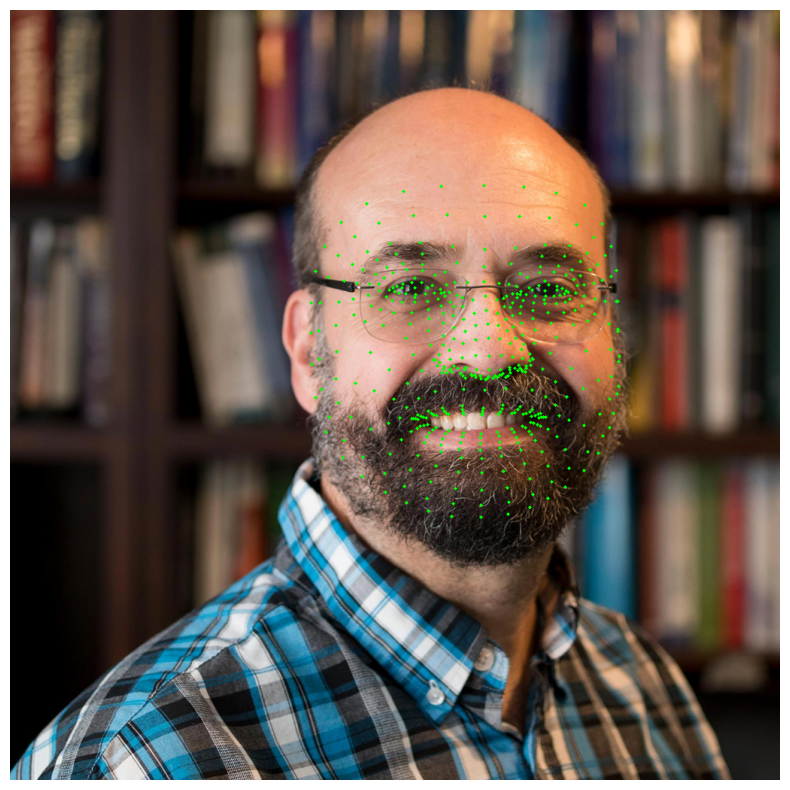

Detected faces: 1
Landmarks on first face: 478


In [4]:
# =========================
# Load image and run inference
# =========================
download_file(MODEL_URL, MODEL_PATH)

rgb = load_image_from_url(IMAGE_URL)
rgb = resize_to_width(rgb, TARGET_WIDTH)

print(f"Resized image shape: {rgb.shape}")

mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=rgb,
)

detector = create_face_landmarker(MODEL_PATH)
result = detector.detect(mp_image)

annotated = draw_landmarks(rgb, result)
display_image(annotated)

print(f"Detected faces: {len(result.face_landmarks)}")
print(f"Landmarks on first face: {len(result.face_landmarks[0]) if result.face_landmarks else 0}")